# Demo for Bi-fidelity Stochastic Subspace Descent

We use dual form of the kernel ridge regression 
$$f(\mathbf{\alpha}; \tau, \mathbf{K}, \mathbf{y}) = \mathbf{\alpha}^T\mathbf{K}\mathbf{\alpha} - 2\langle \mathbf{\alpha},\mathbf{y}\rangle + \tau\lVert \mathbf{\alpha}\rVert^2.$$
We set $\tau = 1$, LF function with kernel matrix approximated by Nystroem method. The optimal solution for this optimization is 
$$\mathbf{\alpha}^* = (\mathbf{K}+\tau\mathbf{I})^{-1}\mathbf{y}.$$


In [84]:
import numpy as np
from sklearn.kernel_approximation import Nystroem
from sklearn.metrics.pairwise import pairwise_kernels
from wrapper import *
import matplotlib.pyplot as plt
from numpy.linalg import norm
# FIX RANDOM SEED
np.random.seed(0)
d, lr = int(1e2), 10
X = np.random.randn(d, 2)
y = np.random.randn(d)
tau = 0.1

In [85]:
K = pairwise_kernels(X, metric='rbf') # kernel matrix
L_prime = Nystroem(kernel='rbf', n_components=lr).fit_transform(X) # low-rank approximation
K_prime = L_prime @ L_prime.T # low-rank kernel matrix
# define functions
def A_HF(a):
    a = a.ravel()
    return a @ K @ a - 2 * a @ y + tau * (a @ a)
def f_LF(a):
    a = a.ravel()
    return a @ K_prime @ a - 2 * a @ y + tau * (a @ a)

# Optimal value
a_opt = np.linalg.solve(K + tau * np.eye(d), y)
A_opt = A_HF(a_opt)
f_HF = lambda a: A_HF(a) - A_opt

ev, _ = np.linalg.eigh(K)
lmbd = 2 * (ev[-1] + tau)

In [103]:
obj = objectiveFcn(f_HF,label='kernel')
obj_lowFi= objectiveFcn(f_LF,label='kernel-LF')
obj_alt = objectiveFcn(f_HF,label='kernel-alt')

# initial point
x0 = np.zeros(d)
learning_rate = 1/lmbd
ell = 10
num_iterations = 500
learning_rate_ssd = learning_rate*ell/d
numLineIter = 50
c = 0.95

In [104]:
from tqdm import tqdm
num_trials = 1
gd, cd, ssdd, spsa_ls, rgfm, ssdd_ls, ssdh_ls, ssdd_bt, ssdd_hbt = [], [], [], [], [], [], [], [], []
for i in tqdm(range(num_trials)):
    # Gradient Descent
    _ = grad_desc(x0,obj,learning_rate=learning_rate,num_iterations=num_iterations)
    gd.append(obj.returnHistory())
    # Coordinate Descent
    _ = coor_desc(x0,obj,learning_rate=learning_rate,num_iterations=num_iterations/2)
    cd.append(obj.returnHistory())
    # SSD
    _ = ssd(x0,obj,ell=ell,learning_rate=learning_rate_ssd,num_iterations=num_iterations*d/ell)
    ssdd.append(obj.returnHistory())
    # SPSA
    _ = spsa(x0,obj,num_iterations=num_iterations*d)
    spsa_ls.append(obj.returnHistory())
    # Random Gredien-free Minimization
    _ = ssd(x0,obj,ell=1,learning_rate=learning_rate/d,num_iterations=num_iterations*d)
    rgfm.append(obj.returnHistory())
    # SSD with linesearch (LF)
    _ = ssd_ls(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_lowFi,
                num_iterations=num_iterations*d/ell, linesearchIter=numLineIter )
    ssdd_ls.append(obj.returnHistory())
        # SSD with linesearch (HF)
    _ = ssd_ls(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_alt,
                num_iterations=num_iterations*d/ell, linesearchIter=numLineIter )
    ssdh_ls.append(obj.returnHistory())
    # SSD with backtracking linesearch (BF)
    _ = ssd_bt(x0,obj,ell=ell,obj_lowFi= obj_lowFi, c=c,
                num_iterations=num_iterations*d/ell, linesearchIter=numLineIter )
    ssdd_bt.append(obj.returnHistory())
    # SSD with backtracking linesearch (HF)
    _ = ssd_hbt(x0,obj,ell=ell,obj_lowFi= obj_lowFi, c=c,
                num_iterations=num_iterations*d/ell, linesearchIter=numLineIter )
    ssdd_hbt.append(obj.returnHistory())
gd, cd, ssdd, ssdd_ls, ssdh_ls, spsa_ls, rgfm, ssdd_bt, ssdd_hbt = np.asarray(gd), np.asarray(cd), np.asarray(ssdd), np.asarray(ssdd_ls), np.asarray(ssdh_ls), np.asarray(spsa_ls), np.asarray(rgfm), np.asarray(ssdd_bt), np.asarray(ssdd_hbt)

  0%|          | 0/1 [00:00<?, ?it/s]

======== gradient descent ======
======== coordinate descent ========
======== SSD ===================
======== SPSA ===================
======== SSD ===================
======== SSD w/ low-fi linesearch =
======== SSD w/ low-fi linesearch =
======== SSD w/ backtracking bi-fi linesearch =
======== SSD w/ backtracking linesearch =


100%|██████████| 1/1 [02:40<00:00, 160.97s/it]


In [105]:
T = d * num_iterations

gd_mean, gd_std = np.mean(gd[:,10:T], axis=0), np.std(gd[:,10:T], axis=0)
cd_mean, cd_std = np.mean(cd[:,10:T], axis=0), np.std(cd[:,10:T], axis=0)
ssd_mean, ssd_std = np.mean(ssdd[:,10:T], axis=0), np.std(ssdd[:,10:T], axis=0)
spsa_mean, spsa_std = np.mean(spsa_ls[:,10:T], axis=0), np.std(spsa_ls[:,10:T], axis=0)
rgfm_mean, rgfm_std = np.mean(rgfm[:,10:T], axis=0), np.std(rgfm[:,10:T], axis=0)
ssd_ls_mean, ssd_ls_std = np.mean(ssdd_ls[:,10:T], axis=0), np.std(ssdd_ls[:,10:T], axis=0)
ssdh_ls_mean, ssdh_ls_std = np.mean(ssdh_ls[:,10:T], axis=0), np.std(ssdh_ls[:,10:T], axis=0)
ssd_bt_mean, ssd_bt_std = np.mean(ssdd_bt[:,10:T], axis=0), np.std(ssdd_bt[:,10:T], axis=0)
ssd_hbt_mean, ssd_hbt_std = np.mean(ssdd_hbt[:,10:T], axis=0), np.std(ssdd_hbt[:,10:T], axis=0)
# ssd_ls_cal_mean, ssd_ls_cal_std = np.mean(ssdd_ls_cal[:,10:400], axis=0), np.std(ssdd_ls_cal[:,10:400], axis=0)

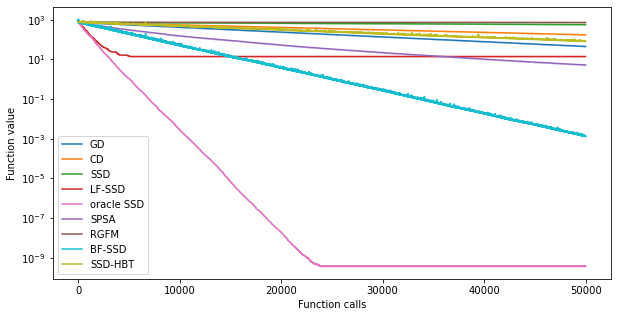

In [106]:
plt.figure(figsize=(10,5))
plt.plot(gd_mean, label='GD', color='tab:blue')
plt.fill_between(range(len(gd_mean)), gd_mean-1.94*gd_std, gd_mean+1.94*gd_std, alpha=0.2, color='tab:blue')
plt.plot(cd_mean, label='CD', color='tab:orange')
plt.fill_between(range(len(cd_mean)), cd_mean-1.94*cd_std, cd_mean+1.94*cd_std, alpha=0.2, color='tab:orange')
plt.plot(ssd_mean, label='SSD', color='tab:green')
plt.fill_between(range(len(ssd_mean)), ssd_mean-1.94*ssd_std, ssd_mean+1.94*ssd_std, alpha=0.2, color='tab:green')
plt.plot(ssd_ls_mean, label='LF-SSD', color='tab:red')
plt.fill_between(range(len(ssd_ls_mean)), ssd_ls_mean-1.94*ssd_ls_std, ssd_ls_mean+1.94*ssd_ls_std, alpha=0.2, color='tab:red')
plt.plot(ssdh_ls_mean, label='oracle SSD', color='tab:pink')
plt.fill_between(range(len(ssdh_ls_mean)), ssdh_ls_mean-1.94*ssdh_ls_std, ssdh_ls_mean+1.94*ssdh_ls_std, alpha=0.2, color='tab:pink')
plt.plot(spsa_mean, label='SPSA', color='tab:purple')
plt.fill_between(range(len(spsa_mean)), spsa_mean-1.94*spsa_std, spsa_mean+1.94*spsa_std, alpha=0.2, color='tab:purple')
plt.plot(rgfm_mean, label='RGFM', color='tab:brown')
plt.fill_between(range(len(rgfm_mean)), rgfm_mean-1.94*rgfm_std, rgfm_mean+1.94*rgfm_std, alpha=0.2, color='tab:brown')
plt.plot(ssd_bt_mean, label='BF-SSD', color='tab:cyan')
plt.fill_between(range(len(ssd_bt_mean)), ssd_bt_mean-1.94*ssd_bt_std, ssd_bt_mean+1.94*ssd_bt_std, alpha=0.2, color='tab:cyan')
plt.plot(ssd_hbt_mean, label='SSD-HBT', color='tab:olive')
plt.fill_between(range(len(ssd_hbt_mean)), ssd_hbt_mean-1.94*ssd_hbt_std, ssd_hbt_mean+1.94*ssd_hbt_std, alpha=0.2, color='tab:olive')
plt.yscale('log')
# plt.xlim(0, 1000)
plt.xlabel('Function calls'), plt.ylabel('Function value'), plt.legend()
# plt.savefig('BF-SSD-d2000-tikhonov.png', dpi=300, bbox_inches='tight')
plt.show()